 # Sistema de Recomendação de Perfumes Nacionais
 **Projeto 1 · Introdução a Inteligência Artificial · UnB 2026/1**

 Sistema de recomendação para uma loja virtual de perfumes nacionais, combinando dois modelos:

 - **TF-IDF** - gera candidatos com base nas preferências declaradas pelo usuário no formulário (família olfativa, ocasião, faixa de preço)
 - **SVD** - reordena os candidatos usando a matriz de utilidade de 500 usuários, priorizando perfumes bem avaliados por usuários com perfil similar

 Essa abordagem híbrida resolve o problema de novos usuários sem histórico, onde eles vão receber recomendações pelo TF-IDF, que são então refinadas pelo SVD.

 ## 1. Carregamento dos dados

In [ ]:
import pandas as pd

# carregando o csv
df_produtos = pd.read_csv("../dados/produtos.csv")
df_produtos.head()

,id,nome,marca,genero,familia_olfativa,notas_olfativas,ocasiao,preco,imagem_path
0,1,Malbec Tradicional,O Boticário,masculino,amadeirado aromatico,"bergamota, lavanda, cedro, vetiver, patchouli",noturno-formal,189.9,imagens/01_malbec_tradicional
1,2,Malbec Black,O Boticário,masculino,amadeirado especiado,"canela, pimenta rosa, cedro, couro, whisky",noturno-inverno,179.9,imagens/02_malbec_black
2,3,Lily Essence,O Boticário,feminino,floral,"lirio, rosa, iris, ambar, baunilha",noturno-formal,159.9,imagens/03_lily_essence
3,4,Lily Absolu,O Boticário,feminino,floral oriental,"lirio, jasmim, patchouli, baunilha, ambar",noturno-inverno,319.9,imagens/04_lily_absolu
4,5,Coffee Man Duo,O Boticário,masculino,amadeirado aromatico,"cafe, bergamota, gengibre, patchouli, sandalo",diurno-casual,149.9,imagens/05_coffee_man_duo


In [ ]:
df_matriz = pd.read_csv('../dados/matriz_utilidade.csv', index_col='usuario_id')
df_matriz.head()

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p41,p42,p43,p44,p45,p46,p47,p48,p49,p50
usuario_id,,,,,,,,,,,,,,,,,,,,,
u1,0,0,0,0,4,0,1,0,0,0,...,2,0,2,0,0,0,0,0,0,5
u2,0,0,0,0,0,0,0,0,0,0,...,0,3,0,0,0,0,2,0,0,0
u3,0,0,3,0,0,2,0,0,0,3,...,0,0,0,0,0,0,3,4,0,0
u4,1,0,0,3,0,0,4,3,0,5,...,0,0,0,0,0,0,3,0,0,0
u5,0,3,0,0,3,0,0,0,0,0,...,0,0,0,3,0,0,1,0,0,0


 ## 2. Análise Exploratória dos Dados (EDA)

 ### 2.1 Visão geral dos datasets

In [ ]:
print(df_produtos.info())
print(f'\n#########')
print(df_produtos.describe())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50 non-null     int64  
 1   nome              50 non-null     str    
 2   marca             50 non-null     str    
 3   genero            50 non-null     str    
 4   familia_olfativa  50 non-null     str    
 5   notas_olfativas   50 non-null     str    
 6   ocasiao           50 non-null     str    
 7   preco             50 non-null     float64
 8   imagem_path       50 non-null     str    
dtypes: float64(1), int64(1), str(7)
memory usage: 3.6 KB
None

#########
             id       preco
count  50.00000   50.000000
mean   25.50000  156.000000
std    14.57738   56.082028
min     1.00000   69.900000
25%    13.25000  129.900000
50%    25.50000  149.900000
75%    37.75000  179.900000
max    50.00000  319.900000


 O catálogo possui 50 perfumes com 9 colunas: id, nome, marca, gênero, família olfativa, notas olfativas, ocasião, preço e caminho da imagem.
 Não há valores nulos. Os preços variam de R$69,90 a R$319,90, com média em torno de R$156.

In [ ]:
print(df_matriz.info())
print(f'\n#########')
print(df_matriz.describe())

<class 'pandas.DataFrame'>
Index: 500 entries, u1 to u500
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   p1      500 non-null    int64
 1   p2      500 non-null    int64
 2   p3      500 non-null    int64
 3   p4      500 non-null    int64
 4   p5      500 non-null    int64
 5   p6      500 non-null    int64
 6   p7      500 non-null    int64
 7   p8      500 non-null    int64
 8   p9      500 non-null    int64
 9   p10     500 non-null    int64
 10  p11     500 non-null    int64
 11  p12     500 non-null    int64
 12  p13     500 non-null    int64
 13  p14     500 non-null    int64
 14  p15     500 non-null    int64
 15  p16     500 non-null    int64
 16  p17     500 non-null    int64
 17  p18     500 non-null    int64
 18  p19     500 non-null    int64
 19  p20     500 non-null    int64
 20  p21     500 non-null    int64
 21  p22     500 non-null    int64
 22  p23     500 non-null    int64
 23  p24     500 non-null    int64

 A matriz possui 500 usuários × 50 perfumes. A maioria das células é 0 (não avaliado).
 As notas reais (1–5) serão analisadas mais a frente.

 ### 2.2 Distribuição do catálogo de produtos

In [ ]:
# agrupando os perfumes por marca para plotar
perfume_por_marca = df_produtos.groupby(['marca']).agg(total=('nome','count')).sort_values('total', ascending=False).reset_index()
perfume_por_marca

,marca,total
0,O Boticário,18
1,Natura,17
2,Avon,7
3,Eudora,4
4,Mahogany,2
5,Granado,1
6,Phebo,1


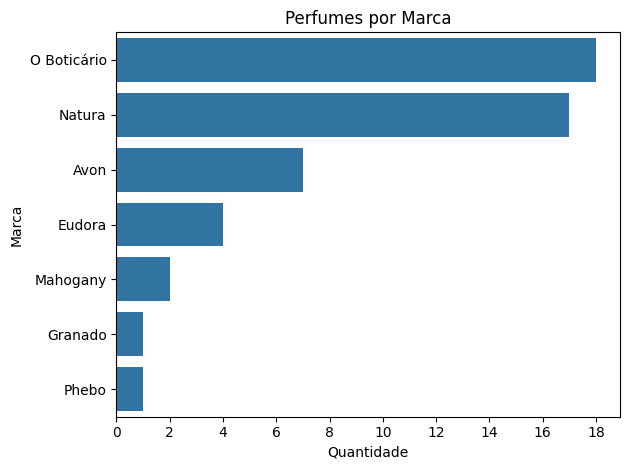

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="total", y="marca", data=perfume_por_marca)
plt.title("Perfumes por Marca")
plt.xlabel("Quantidade")
plt.ylabel("Marca")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

 Boticário e Natura dominam aparecem mais vezes no catálogo.
 Avon contribui com 7 perfumes, Eudora com 4, e Mahogany, Granado e Phebo com 1–2 cada.

In [ ]:
# agrupando perfume por familia olfativa para plotar
perfume_por_familia = df_produtos.groupby(['familia_olfativa']).agg(total=('nome','count')).sort_values('total', ascending=False).reset_index()
perfume_por_familia

,familia_olfativa,total
0,amadeirado aromatico,8
1,floral,7
2,amadeirado,4
3,aromatico aquatico,3
4,aromatico,3
5,floral oriental,3
6,amadeirado oriental,3
7,gourmand,2
8,chipre frutal,2
9,floral frutal,2


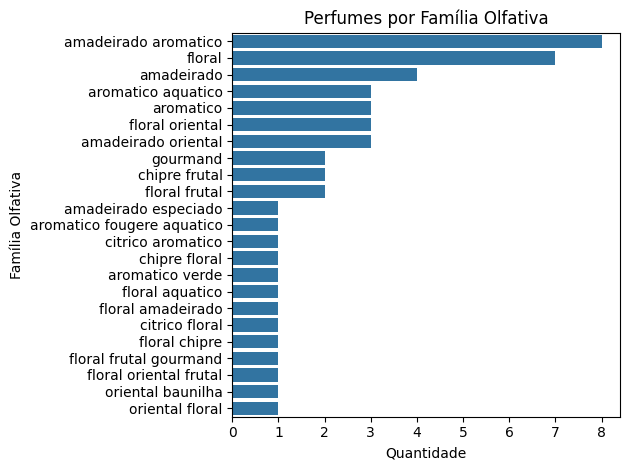

In [ ]:
sns.barplot(x="total", y="familia_olfativa", data=perfume_por_familia)
plt.title("Perfumes por Família Olfativa")
plt.xlabel("Quantidade")
plt.ylabel("Família Olfativa")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

 O catálogo é bastante diversificado: 22 famílias olfativas diferentes. As mais representadas são
 amadeirado aromático e floral. A maioria das famílias porém aparece apenas uma vez

In [ ]:
# agrupando perfume por genero para plotar
perfume_por_genero = df_produtos.groupby(['genero']).agg(total=('nome','count')).sort_values('total', ascending=False).reset_index()
perfume_por_genero

,genero,total
0,feminino,25
1,masculino,24
2,unissex,1


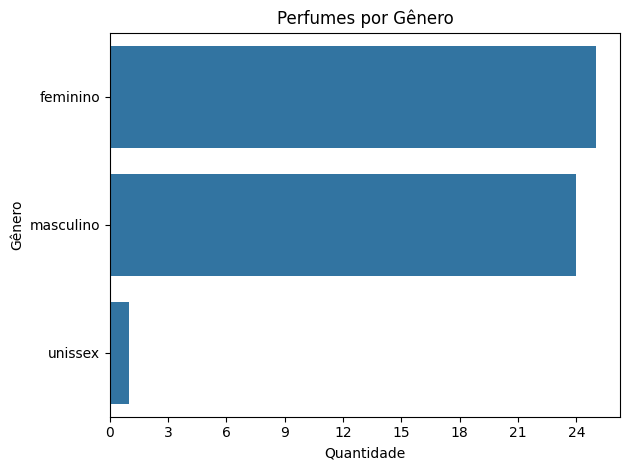

In [ ]:
sns.barplot(x="total", y="genero", data=perfume_por_genero)
plt.title("Perfumes por Gênero")
plt.xlabel("Quantidade")
plt.ylabel("Gênero")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

 O catálogo é equilibrado entre feminino e masculino, mas tem apenas 1 perfume unissex.

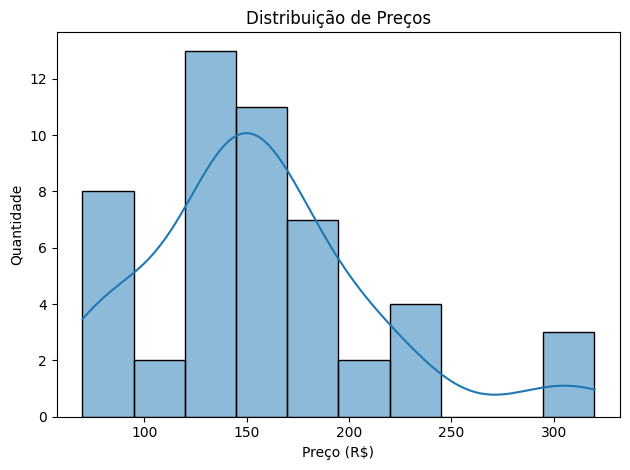

In [ ]:
sns.histplot(data=df_produtos, x="preco", kde=True)
plt.title("Distribuição de Preços")
plt.xlabel("Preço (R$)")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

 A distribuição de preços é assimétrica a direita. A maioria dos perfumes se concentra entre R$120 e R$170,
 com uma cauda de produtos premium acima de R$250.

 ### 2.3 Análise da matriz de utilidade

 Antes de analisar as notas é verificado quantas células não foram avaliadas.
 Isso é esperado em sistemas de recomendação reais: usuários avaliam apenas uma pequena fração dos produtos disponíveis.
 Os zeros serão excluídos nas análises seguintes pois representam ausência de avaliação, não uma nota ruim.

In [ ]:
total = df_matriz.size # total de combinaçoes da matriz
nao_avaliados = (df_matriz == 0).sum().sum() # conta o total de celulas zeradas na matriz
avaliados = total - nao_avaliados # calcula as combinacoes que tem nota de 1 a 5 
media_por_usuario = avaliados / df_matriz.shape[0] # calcula a media de perfumes avaliados por usuario
silenciosos = (df_matriz.sum(axis=1) == 0).sum() # conta os usuarios que nao avaliaram nenhum perfume

print(f"Total de combinações possíveis (usuários x perfumes): {total}")
print(f"Combinações avaliadas (nota 1-5):  {avaliados} ({avaliados/total*100:.1f}%)")
print(f"Combinações não avaliadas (nota 0): {nao_avaliados} ({nao_avaliados/total*100:.1f}%)")
print(f"Média de perfumes avaliados por usuário: {media_por_usuario:.1f}")
print(f"Usuários que nunca avaliaram nenhum perfume: {silenciosos} ({silenciosos/df_matriz.shape[0]*100:.1f}%)")

Total de combinações possíveis (usuários x perfumes): 25000
Combinações avaliadas (nota 1-5):  5678 (22.7%)
Combinações não avaliadas (nota 0): 19322 (77.3%)
Média de perfumes avaliados por usuário: 11.4
Usuários que nunca avaliaram nenhum perfume: 66 (13.2%)


 A maioria dos usuários avaliou apenas uma pequena fração dos 50 perfumes disponíveis, o que é esperado em lojas reais.
 Uma parcela dos usuários não avaliou nenhum produto. Os dados foram gerados dessa forma para simular
 compradores reais que nunca deixam avaliação, tornando a matriz mais próxima de um cenário real.

 ---
 ## O que falta implementar

 ### 2.3 (continuação) — Análise da matriz de utilidade
 - Histograma das notas 1–5 (excluindo zeros)
 - Distribuição de avaliações por usuário (quantos perfumes cada um avaliou)
 - Perfumes mais e menos avaliados

 ### 3. Modelo híbrido

 **3.1 TF-IDF (filtragem por conteúdo)**
 - Referência: https://365datascience.com/tutorials/how-to-build-recommendation-system-in-python/
 - Criar coluna `corpus` combinando `familia_olfativa + notas_olfativas + ocasiao`
 - Vetorizar com `TfidfVectorizer` do scikit-learn
 - Calcular a matriz de similaridade de cosseno entre os perfumes (`cosine_similarity`)
 - Retornar os top-20 perfumes mais similares ao perfil do novo usuário

 **3.2 SVD — filtragem colaborativa (`scikit-surprise`)**
 - Treinar um modelo SVD (Singular Value Decomposition) na matriz de utilidade (500 usuários × 50 perfumes)
 - O SVD aprende padrões latentes: usuários que gostam de amadeirado tendem a gostar de oriental, etc.
 - Para o novo usuário, identificar o usuário existente com perfil mais similar (via formulário)
 - Usar o SVD para prever a nota desse usuário nos top-20 candidatos do TF-IDF
 - Reordenar pelos maiores scores previstos e retornar os top-5 finais

 ### 4. Interface com Gradio
 - Formulário de cadastro (nome, e-mail, gênero)
 - Questionário de preferências (família olfativa, ocasião, faixa de preço)
 - Exibição das recomendações com imagem, nome, marca e preço
 - Campo para o usuário avaliar os perfumes recomendados (escala 1–5)